# Plasma-Induced THz Emission Driven by Nonclassical Light: a Stochastic-Field Simulation

Local photocurrent model of two-color gas-plasma THz generation in which the weak
second harmonic is a **nonclassical stochastic field**: a strong classical 800 nm
fundamental plus one 400 nm mode sampled shot-by-shot from the **Husimi-$Q$**
distribution of bright squeezed vacuum (the coherent-plus-BSV setting of
Wang et al., *PRA* **113**, L021501 (2026); photocurrent template after
Sun & Zhang 2022; current-derivative THz source after Schuh 2013).

Outputs, per the simulation spec
(`wiki/simulations/thz-plasma-photocurrent-bsv-simulation.md`):

1. $g^{(2)}(0)$ of the stochastic driving mode, from the *same* $Q$ samples that
   drive the plasma (antinormal $\to$ normal ordering correction);
2. ensemble **mean and fluctuation of the THz waveform** $E_{\rm THz}(t)$;
3. ensemble **mean and fluctuation of the THz spectrum**, split into the coherent
   part $|\langle \hat E(\nu)\rangle|^2$ and the total $\langle|\hat E(\nu)|^2\rangle$;
4. shot-to-shot THz pulse-energy statistics.

**Symmetry guardrail.** For a zero-mean stochastic drive the ensemble-averaged THz
*field* may vanish even when every shot emits: the per-shot THz polarity follows the
sign of the sampled $2\omega$ quadrature. A near-zero mean waveform with a large
fluctuation band is then the physically meaningful result, not a bug.

**Caveats.** Single-point local current source: no propagation, phase matching, plasma
dispersion, or saturation; no far-field $\omega^2$ factor; THz field in arbitrary units.
The tunneling rate is a quasistatic ADK-like formula with a hydrogen-like prefactor.
Statements about the *emitted THz quantum state* (photon $g^{(2)}$ of the THz light)
are out of scope — the energy fluctuation ratio below is a classical ensemble statistic.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:
    import stochastic_em_theory  # noqa: F401
except ModuleNotFoundError:
    sys.path.insert(0, str((Path.cwd() / ".." / "src").resolve()))

from stochastic_em_theory.fields import sample_single_mode_husimi_q
from stochastic_em_theory.ionization import keldysh_parameter

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "wiki").is_dir() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
print("repo root:", REPO_ROOT)

%matplotlib inline

repo root: /Users/simontsui/Desktop/Research/Projects/stochastic_em_theory


## Parameters

Atomic units internally; time displayed in fs, frequency in THz.
The fundamental is fixed and classical; the $2\omega$ mode is stochastic with its
mean square field normalized per driver state (same mean-intensity matching used in
the Fig. 3b HHG runner).

In [2]:
AU_TIME_S = 2.418884e-17          # 1 a.u. of time in seconds
AU_FREQ_THZ = 1.0 / AU_TIME_S / 1.0e12   # cycles/a.u. -> THz

# field and atom
OMEGA_AU = 0.057                  # 800 nm fundamental
E_FUND_AU = 0.05                  # ~8.8e13 W/cm^2
RMS_2W_FRACTION = 0.15            # rms second-harmonic field / fundamental
IP_AU = 0.579                     # Ar, 15.76 eV

# squeezed mode
BSV_R = 1.5
NBAR = float(np.sinh(BSV_R) ** 2)

# time grid and detection band
DT_AU = 0.5
N_T = 65536                       # window ~792 fs
ENVELOPE_FWHM_FS = 80.0
NU_CUT_THZ = 80.0                 # low-pass cutoff of the THz detection band
NU_PLOT_THZ = 120.0

# ensemble
SHOTS = 4000
BATCH = 250
SEED = 20260610

time_au = np.arange(N_T) * DT_AU
time_fs = time_au * AU_TIME_S * 1.0e15
t_center = time_au[N_T // 2]
sigma_t_au = (ENVELOPE_FWHM_FS * 1.0e-15 / AU_TIME_S) / 2.354820045
envelope = np.exp(-0.5 * ((time_au - t_center) / sigma_t_au) ** 2)

print(f"<n> = sinh^2(r) = {NBAR:.3f};  g2 target = 3 + 1/<n> = {3 + 1/NBAR:.4f}")
print(f"Keldysh parameter at peak: "
      f"{keldysh_parameter(field_amplitude_au=E_FUND_AU, omega_au=OMEGA_AU, ionization_potential_au=IP_AU):.2f}")
print(f"window = {time_fs[-1]:.0f} fs, dnu = {AU_FREQ_THZ / (N_T * DT_AU):.2f} THz")

<n> = sinh^2(r) = 4.534;  g2 target = 3 + 1/<n> = 3.2206
Keldysh parameter at peak: 1.23
window = 793 fs, dnu = 1.26 THz


## Driver ensembles and their $g^{(2)}(0)$

Per shot, the second-harmonic field is
$E_{2\omega}(t) = s\,f(t)\,[\,x_\beta \cos(2\omega_0 t) + p_\beta \sin(2\omega_0 t)\,]$
with $x_\beta = \sqrt2\,\mathrm{Re}\,\beta$, $p_\beta = \sqrt2\,\mathrm{Im}\,\beta$ and
$\beta$ drawn from the Husimi-$Q$ distribution of the state. In the photocurrent
mechanism the $\sin(2\omega_0 t)$ quadrature is THz-active (optimal two-color phase),
the $\cos$ quadrature is THz-inactive.

| case | state of the $2\omega$ mode | THz-relevant property |
|---|---|---|
| `coherent` | $\vert i\sqrt{\bar n}\rangle$ (displacement on the active quadrature) | deterministic reference |
| `bsv_active` | squeezed vacuum, **anti-squeezed along the active quadrature** | zero-mean, large active-quadrature noise |
| `bsv_inactive` | same state rotated by $90^\circ$ | identical photon statistics, inactive-quadrature noise |
| `vacuum` | vacuum | sampling noise floor |

$g^{(2)}(0)$ from the $Q$ samples uses the **antinormal ordering correction**
$\langle\hat n\rangle = \langle|\beta|^2\rangle_Q - 1$,
$\langle \hat a^{\dagger2}\hat a^2\rangle = \langle|\beta|^4\rangle_Q
 - 4\langle|\beta|^2\rangle_Q + 2$.

         case   <n> est   g2 est  g2 target
     coherent     4.463    1.004      1.000
   bsv_active     4.609    3.103      3.221
 bsv_inactive     4.353    3.035      3.221
       vacuum     0.003      nan        nan


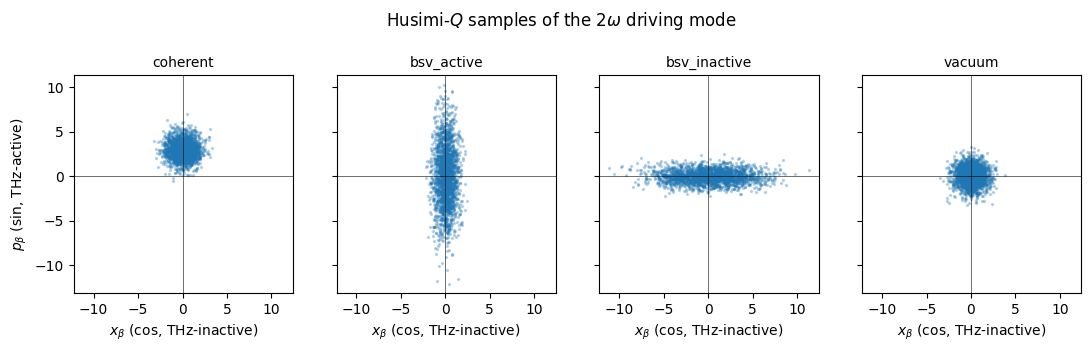

In [3]:
rng = np.random.default_rng(SEED)

def sample_driver(case: str, shots: int) -> np.ndarray:
    if case == "coherent":
        return sample_single_mode_husimi_q(r=0.0, shots=shots, rng=rng) + 1j * np.sqrt(NBAR)
    if case == "bsv_active":      # anti-squeezed quadrature on Im(beta) -> sin(2wt)
        return sample_single_mode_husimi_q(r=BSV_R, phase=0.0, shots=shots, rng=rng)
    if case == "bsv_inactive":    # rotated: anti-squeezed quadrature on Re(beta) -> cos(2wt)
        return sample_single_mode_husimi_q(r=BSV_R, phase=np.pi, shots=shots, rng=rng)
    if case == "vacuum":
        return sample_single_mode_husimi_q(r=0.0, shots=shots, rng=rng)
    raise ValueError(case)

def g2_from_q_samples(beta: np.ndarray) -> tuple[float, float]:
    # (mean photon number, g2) via the antinormal->normal ordering correction
    q2 = float(np.mean(np.abs(beta) ** 2))
    q4 = float(np.mean(np.abs(beta) ** 4))
    n = q2 - 1.0
    g2_numerator = q4 - 4.0 * q2 + 2.0
    return n, g2_numerator / n**2 if n > 0.05 else float("nan")

CASES = ["coherent", "bsv_active", "bsv_inactive", "vacuum"]
beta_by_case = {case: sample_driver(case, SHOTS) for case in CASES}

targets = {"coherent": 1.0, "bsv_active": 3 + 1 / NBAR, "bsv_inactive": 3 + 1 / NBAR,
           "vacuum": float("nan")}
print(f"{'case':>13} {'<n> est':>9} {'g2 est':>8} {'g2 target':>10}")
for case in CASES:
    n_est, g2_est = g2_from_q_samples(beta_by_case[case])
    print(f"{case:>13} {n_est:>9.3f} {g2_est:>8.3f} {targets[case]:>10.3f}")

fig, axes = plt.subplots(1, 4, figsize=(13, 3.2), sharex=True, sharey=True)
for ax, case in zip(axes, CASES):
    beta = beta_by_case[case][:2000]
    ax.scatter(np.sqrt(2) * beta.real, np.sqrt(2) * beta.imag, s=2, alpha=0.25)
    ax.set_title(case, fontsize=10)
    ax.set_xlabel(r"$x_\beta$ (cos, THz-inactive)")
    ax.axhline(0, color="k", lw=0.4); ax.axvline(0, color="k", lw=0.4)
    ax.set_aspect("equal")
axes[0].set_ylabel(r"$p_\beta$ (sin, THz-active)")
fig.suptitle(r"Husimi-$Q$ samples of the $2\omega$ driving mode", y=1.04)
plt.show()

## Photocurrent model

Per shot: quasistatic tunneling rate $w(|E|) = \frac{4(2I_p)^{5/2}}{|E|}
\exp\!\big[-\tfrac{2(2I_p)^{3/2}}{3|E|}\big]$, electron fraction
$n_e(t) = 1 - \exp[-\int^t w\,dt']$ (no depletion at these intensities), and the
radiating source $\partial_t J = E(t)\,n_e(t)$ (free-electron acceleration). The THz
waveform is the low-pass-filtered source, $E_{\rm THz}(t) \propto
\mathrm{LP}_{\nu_c}[E(t)\,n_e(t)]$, with a smooth super-Gaussian cutoff at
$\nu_c = 80$ THz and the DC bin removed (radiated fields carry no DC).

Ensembles are processed in batches, accumulating running sums for the mean and
variance of the waveform and of the intensity spectrum, the complex mean spectrum
(coherent part), and per-shot THz pulse energies.

In [4]:
ADK_PREFACTOR = 4.0 * (2.0 * IP_AU) ** 2.5
ADK_EXPONENT = 2.0 * (2.0 * IP_AU) ** 1.5 / 3.0

cos_w = np.cos(OMEGA_AU * time_au)
cos_2w = np.cos(2.0 * OMEGA_AU * time_au)
sin_2w = np.sin(2.0 * OMEGA_AU * time_au)

freqs_thz = np.fft.rfftfreq(N_T, d=DT_AU) * AU_FREQ_THZ
lowpass = np.exp(-((freqs_thz / NU_CUT_THZ) ** 8))
lowpass[0] = 0.0
keep = freqs_thz <= NU_PLOT_THZ
freqs_keep = freqs_thz[keep]

def tunneling_rate(abs_field: np.ndarray) -> np.ndarray:
    safe = np.maximum(abs_field, 1.0e-8)
    with np.errstate(over="ignore"):
        rate = ADK_PREFACTOR / safe * np.exp(-ADK_EXPONENT / safe)
    return np.where(abs_field > 1.0e-6, rate, 0.0)

def run_case(beta: np.ndarray, n_example_shots: int = 3) -> dict:
    s_scale = RMS_2W_FRACTION * E_FUND_AU / np.sqrt(np.mean(np.abs(beta) ** 2))
    sum_w = np.zeros(N_T)
    sumsq_w = np.zeros(N_T)
    sum_spec = np.zeros(keep.sum(), dtype=np.complex128)
    sum_int = np.zeros(keep.sum())
    sumsq_int = np.zeros(keep.sum())
    energies = np.empty(beta.size)
    examples = []
    for start in range(0, beta.size, BATCH):
        chunk = beta[start:start + BATCH]
        x_b = np.sqrt(2.0) * chunk.real
        p_b = np.sqrt(2.0) * chunk.imag
        field = envelope[None, :] * (
            E_FUND_AU * cos_w[None, :]
            + s_scale * (x_b[:, None] * cos_2w[None, :] + p_b[:, None] * sin_2w[None, :])
        )
        rate = tunneling_rate(np.abs(field))
        n_e = 1.0 - np.exp(-np.cumsum(rate, axis=1) * DT_AU)
        source = field * n_e
        spectrum = np.fft.rfft(source, axis=1) * lowpass[None, :]
        thz = np.fft.irfft(spectrum, n=N_T, axis=1)
        sum_w += thz.sum(axis=0)
        sumsq_w += (thz ** 2).sum(axis=0)
        sum_spec += spectrum[:, keep].sum(axis=0)
        intensity = np.abs(spectrum[:, keep]) ** 2
        sum_int += intensity.sum(axis=0)
        sumsq_int += (intensity ** 2).sum(axis=0)
        energies[start:start + chunk.size] = (thz ** 2).sum(axis=1) * DT_AU
        if start == 0:
            examples = thz[:n_example_shots].copy()
    shots = beta.size
    mean_w = sum_w / shots
    std_w = np.sqrt(np.maximum(sumsq_w / shots - mean_w ** 2, 0.0))
    mean_int = sum_int / shots
    std_int = np.sqrt(np.maximum(sumsq_int / shots - mean_int ** 2, 0.0))
    return {
        "mean_waveform": mean_w,
        "std_waveform": std_w,
        "coherent_spectrum": np.abs(sum_spec / shots) ** 2,
        "mean_intensity_spectrum": mean_int,
        "std_intensity_spectrum": std_int,
        "energies": energies,
        "examples": examples,
        "final_ionization_mean": float(n_e[:, -1].mean()),
    }

results = {}
for case in CASES:
    results[case] = run_case(beta_by_case[case])
    print(f"{case:>13}: mean final ionized fraction (last batch) = "
          f"{results[case]['final_ionization_mean']:.2e}")

     coherent: mean final ionized fraction (last batch) = 4.24e-03


   bsv_active: mean final ionized fraction (last batch) = 5.91e-03


 bsv_inactive: mean final ionized fraction (last batch) = 1.22e-02


       vacuum: mean final ionized fraction (last batch) = 7.51e-03


## THz waveforms: ensemble mean and shot-to-shot fluctuation

Solid line: $\langle E_{\rm THz}(t)\rangle$. Shaded band: $\pm 1\sigma(t)$ across the
ensemble. Thin lines: individual shots. The coherent case is deterministic up to
sampled vacuum noise; both zero-mean BSV cases have $\langle E_{\rm THz}\rangle \approx 0$
with the *fluctuation* carrying the emission — and the fluctuation band collapses when
the anti-squeezed quadrature is rotated onto the THz-inactive quadrature.

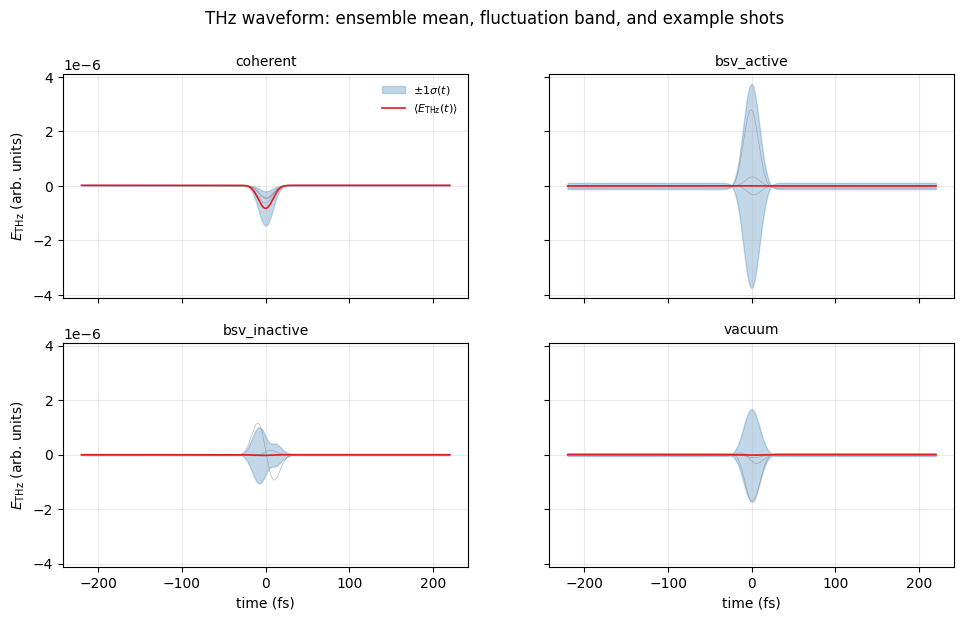

         case     max|<E>|    max sigma    ratio
     coherent    8.217e-07    6.273e-07    1.310
   bsv_active    4.941e-09    3.737e-06    0.001
 bsv_inactive    2.488e-08    1.030e-06    0.024
       vacuum    1.301e-08    1.687e-06    0.008


In [5]:
window = (time_fs > time_fs[N_T // 2] - 220.0) & (time_fs < time_fs[N_T // 2] + 220.0)
t_plot = time_fs[window] - time_fs[N_T // 2]

fig, axes = plt.subplots(2, 2, figsize=(11.5, 6.4), sharex=True, sharey=True)
for ax, case in zip(axes.flat, CASES):
    res = results[case]
    for shot in res["examples"]:
        ax.plot(t_plot, shot[window], lw=0.5, color="gray", alpha=0.55)
    ax.fill_between(
        t_plot,
        (res["mean_waveform"] - res["std_waveform"])[window],
        (res["mean_waveform"] + res["std_waveform"])[window],
        alpha=0.3, color="#377eb8", label=r"$\pm 1\sigma(t)$",
    )
    ax.plot(t_plot, res["mean_waveform"][window], lw=1.2, color="#e41a1c",
            label=r"$\langle E_{\rm THz}(t)\rangle$")
    ax.set_title(case, fontsize=10)
    ax.grid(alpha=0.25)
for ax in axes[1]:
    ax.set_xlabel("time (fs)")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$E_{\rm THz}$ (arb. units)")
axes[0, 0].legend(fontsize=8, frameon=False)
fig.suptitle("THz waveform: ensemble mean, fluctuation band, and example shots")
plt.show()

peak_mean = {case: float(np.max(np.abs(results[case]["mean_waveform"]))) for case in CASES}
peak_std = {case: float(np.max(results[case]["std_waveform"])) for case in CASES}
print(f"{'case':>13} {'max|<E>|':>12} {'max sigma':>12} {'ratio':>8}")
for case in CASES:
    print(f"{case:>13} {peak_mean[case]:>12.3e} {peak_std[case]:>12.3e} "
          f"{peak_mean[case] / peak_std[case]:>8.3f}")

## THz spectra: coherent part, total, and fluctuation

Total (incoherent) spectrum $\langle|\hat E(\nu)|^2\rangle$ versus the coherent part
$|\langle\hat E(\nu)\rangle|^2$, with the shaded band showing $\pm1\sigma$ of the
per-shot intensity spectrum. For the coherent drive the two coincide; for the
THz-active BSV drive the emission is almost entirely incoherent (thermal-like), with
per-shot intensity fluctuations comparable to the mean.

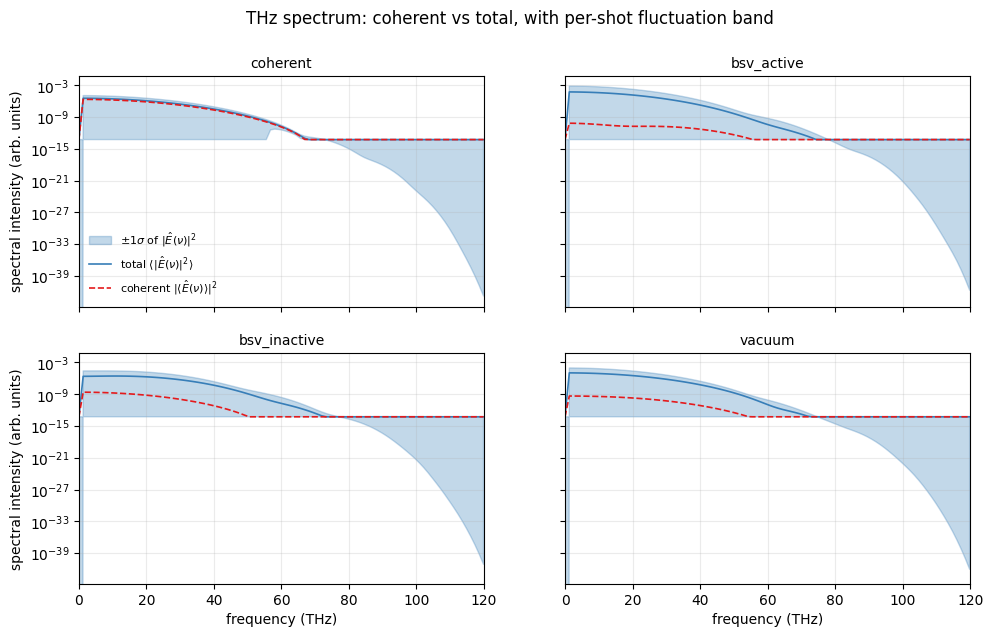

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11.5, 6.6), sharex=True, sharey=True)
floor = max(res["mean_intensity_spectrum"].max() for res in results.values()) * 1e-9
for ax, case in zip(axes.flat, CASES):
    res = results[case]
    mean_int = res["mean_intensity_spectrum"]
    ax.fill_between(
        freqs_keep,
        np.maximum(mean_int - res["std_intensity_spectrum"], floor),
        mean_int + res["std_intensity_spectrum"],
        alpha=0.3, color="#377eb8", label=r"$\pm 1\sigma$ of $|\hat E(\nu)|^2$",
    )
    ax.semilogy(freqs_keep, np.maximum(mean_int, floor), color="#377eb8", lw=1.2,
                label=r"total $\langle|\hat E(\nu)|^2\rangle$")
    ax.semilogy(freqs_keep, np.maximum(res["coherent_spectrum"], floor), color="#e41a1c",
                lw=1.2, ls="--", label=r"coherent $|\langle\hat E(\nu)\rangle|^2$")
    ax.set_title(case, fontsize=10)
    ax.grid(alpha=0.25)
for ax in axes[1]:
    ax.set_xlabel("frequency (THz)")
for ax in axes[:, 0]:
    ax.set_ylabel("spectral intensity (arb. units)")
axes[0, 0].legend(fontsize=8, frameon=False)
axes[0, 0].set_xlim(0, NU_PLOT_THZ)
fig.suptitle("THz spectrum: coherent vs total, with per-shot fluctuation band")
plt.show()

## THz pulse-energy statistics

Shot-to-shot distribution of the THz pulse energy $U = \int E_{\rm THz}^2\,dt$ and its
classical fluctuation ratio $\langle U^2\rangle/\langle U\rangle^2$. For the THz-active
BSV case the energy follows the anti-squeezed quadrature power (approximately
$\chi^2_1$), so the ratio approaches 3 — *bunched, thermal-like* THz energy
statistics from a quadrature-noise-driven plasma, consistent with the Wang 2026
prediction. This is a statement about the stochastic ensemble, not a measured THz
photon correlation.

         case         <U>       std U  <U^2>/<U>^2  batch SE of <U>
     coherent   6.948e-10   1.484e-09        5.562         2.04e-11
   bsv_active   9.891e-09   1.144e-07      134.834         1.53e-09
 bsv_inactive   7.699e-10   5.885e-09       59.422         8.80e-11
       vacuum   2.053e-09   1.444e-08       50.435         2.28e-10


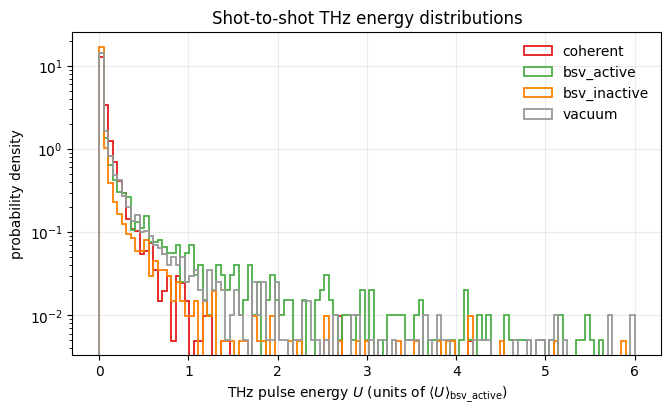

In [7]:
batch_count = SHOTS // BATCH
print(f"{'case':>13} {'<U>':>11} {'std U':>11} {'<U^2>/<U>^2':>12} {'batch SE of <U>':>16}")
energy_stats = {}
for case in CASES:
    u = results[case]["energies"]
    ratio = float(np.mean(u ** 2) / np.mean(u) ** 2)
    batch_means = u.reshape(batch_count, -1).mean(axis=1)
    se = float(batch_means.std(ddof=1) / np.sqrt(batch_count))
    energy_stats[case] = {"mean": float(u.mean()), "std": float(u.std()),
                          "fluctuation_ratio": ratio, "batch_se": se}
    print(f"{case:>13} {u.mean():>11.3e} {u.std():>11.3e} {ratio:>12.3f} {se:>16.2e}")

fig, ax = plt.subplots(figsize=(7.6, 4.2))
u_ref = results["bsv_active"]["energies"].mean()
bins = np.linspace(0.0, 6.0, 120)
for case, color in zip(CASES, ("#e41a1c", "#4daf4a", "#ff7f00", "#999999")):
    ax.hist(results[case]["energies"] / u_ref, bins=bins, histtype="step",
            density=True, lw=1.3, color=color, label=case)
ax.set_yscale("log")
ax.set_xlabel(r"THz pulse energy $U$ (units of $\langle U\rangle_{\rm bsv\_active}$)")
ax.set_ylabel("probability density")
ax.set_title("Shot-to-shot THz energy distributions")
ax.legend(frameon=False)
ax.grid(alpha=0.25)
plt.show()

## Record the run

Write a summary JSON and manifest into a dated `results/` directory, per the
directory contract.

In [8]:
from datetime import date
from stochastic_em_theory.io import current_git_commit, ensure_output_dir, write_json, write_manifest

output_dir = ensure_output_dir(REPO_ROOT / "results" / f"thz-plasma-photocurrent-notebook-{date.today():%Y%m%d}")
summary = {
    "parameters": {
        "omega_au": OMEGA_AU, "fundamental_field_au": E_FUND_AU,
        "rms_2w_fraction": RMS_2W_FRACTION, "ionization_potential_au": IP_AU,
        "bsv_r": BSV_R, "nbar": NBAR, "dt_au": DT_AU, "time_points": N_T,
        "envelope_fwhm_fs": ENVELOPE_FWHM_FS, "lowpass_cutoff_thz": NU_CUT_THZ,
        "shots": SHOTS, "seed": SEED,
    },
    "driver_g2": {case: dict(zip(("n_est", "g2_est"), g2_from_q_samples(beta_by_case[case])))
                  for case in CASES},
    "g2_targets": {case: targets[case] for case in CASES},
    "thz_energy_stats": energy_stats,
    "peak_mean_waveform": peak_mean,
    "peak_std_waveform": peak_std,
}
write_json(output_dir / "thz_plasma_photocurrent_summary.json", summary)
write_manifest(output_dir / "manifest.yaml", {
    "run_id": output_dir.name,
    "created": date.today().isoformat(),
    "code_entrypoint": "code/notebooks/thz_plasma_stochastic.ipynb",
    "generator": "code/notebooks/build_thz_plasma_stochastic_notebook.py",
    "git_commit": current_git_commit(REPO_ROOT),
    "random_seeds": [SEED],
    "observable": "thz_waveform_spectrum_mean_and_fluctuation_plus_driver_g2",
    "mechanism": "two_color_plasma_photocurrent_coherent_plus_stochastic_2w",
    "representation": "Husimi-Q sampling of the 2w mode; antinormal-ordering-corrected g2",
    "units": "atomic units internally; fs and THz axes; THz field in arbitrary units",
    "parameters": summary["parameters"],
    "source_refs": [
        "wiki/simulations/thz-plasma-photocurrent-bsv-simulation.md",
        "wiki/sources/wang-2026-quantum-thz-plasma-bsv.md",
        "wiki/sources/sun-2022-thz-laser-induced-plasma.md",
        "wiki/sources/schuh-2013-thz-ionization-gases.md",
    ],
    "notes": (
        "Local single-point photocurrent model: no propagation, phase matching, plasma "
        "dispersion, or far-field omega^2 factor; quasistatic ADK-like rate; energy "
        "fluctuation ratio is a classical ensemble statistic, not a THz photon g2."
    ),
})
print(output_dir)

/Users/simontsui/Desktop/Research/Projects/stochastic_em_theory/results/thz-plasma-photocurrent-notebook-20260610


## Summary

- The driving-field diagnostic and the plasma simulation use one consistent stochastic
  ensemble: Husimi-$Q$ samples whose ordering-corrected $g^{(2)}(0)$ reproduces the
  quantum-optics targets ($1$ coherent, $3 + 1/\bar n$ squeezed vacuum), while the same
  samples drive the photocurrent.
- **Symmetry:** zero-mean BSV drives give $\langle E_{\rm THz}(t)\rangle \approx 0$;
  the emission lives entirely in the fluctuations (incoherent spectrum), in contrast to
  the deterministic coherent two-color reference.
- **Quadrature sensitivity:** rotating the anti-squeezed quadrature from the THz-active
  onto the THz-inactive axis suppresses the yield at *identical* photon statistics —
  THz generation is a phase-sensitive probe of the squeezing ellipse, beyond what
  $g^{(2)}(0)$ alone can distinguish.
- **Statistics:** the THz-active BSV energy distribution is strongly bunched
  ($\langle U^2\rangle/\langle U\rangle^2 \approx 3$, $\chi^2_1$-like), consistent with
  the thermal-like THz output predicted by Wang 2026.